# Baseline CNN Results

## Facial Emotion Recognition on FER2013

This notebook documents the **Baseline CNN** stage of the facial emotion recognition project.

The goal of this stage is not to build the best possible model yet. Instead, the purpose is to create a reliable reference model that can later be compared against an improved CNN architecture.

### What this notebook covers

1. Baseline model objective
2. Model architecture overview
3. Training history analysis
4. Validation performance
5. Test-set performance
6. Classification report
7. Confusion matrix
8. Main error patterns
9. Summary and next steps

### Dataset

The model is trained and evaluated on the FER2013 dataset, which contains grayscale facial images of size **48 × 48** pixels across seven emotion classes.

| Label | Emotion |
|---:|---|
| 0 | Angry |
| 1 | Disgust |
| 2 | Fear |
| 3 | Happy |
| 4 | Sad |
| 5 | Surprise |
| 6 | Neutral |


## 1. Import Required Libraries

This notebook mainly reads previously generated files from the project:

- Training history CSV
- Validation results JSON
- Test metrics JSON
- Classification report TXT
- Confusion matrix image
- Accuracy and loss curve images

The notebook intentionally avoids retraining the model.


In [1]:
from pathlib import Path
import json

from IPython.display import Image, display
import pandas as pd

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Detect Project Paths

The following cell works whether the notebook is launched from the project root directory or from the `notebooks/` directory.

Expected project structure:

```text
facial-emotion-recognition/
├── models/
├── outputs/
│   ├── figures/
│   └── metrics/
├── notebooks/
└── src/
```


In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"

print(f"Project root: {PROJECT_ROOT}")
print(f"Models directory: {MODELS_DIR}")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Metrics directory: {METRICS_DIR}")

Project root: d:\projects\facial-emotion-recognition
Models directory: d:\projects\facial-emotion-recognition\models
Figures directory: d:\projects\facial-emotion-recognition\outputs\figures
Metrics directory: d:\projects\facial-emotion-recognition\outputs\metrics


## 3. Required Files Check

Before analyzing the model results, we verify that the expected baseline output files exist.


In [3]:
required_files = {
    "Best baseline model": MODELS_DIR / "baseline_cnn_best.keras",
    "Final baseline model": MODELS_DIR / "baseline_cnn_final.keras",
    "Model summary": METRICS_DIR / "baseline_cnn_summary.txt",
    "Training history CSV": METRICS_DIR / "baseline_cnn_history.csv",
    "Validation results": METRICS_DIR / "baseline_cnn_validation_results.json",
    "Test metrics": METRICS_DIR / "baseline_cnn_test_metrics.json",
    "Classification report": METRICS_DIR / "baseline_cnn_classification_report.txt",
    "Accuracy curve": FIGURES_DIR / "baseline_cnn_accuracy_curve.png",
    "Loss curve": FIGURES_DIR / "baseline_cnn_loss_curve.png",
    "Confusion matrix": FIGURES_DIR / "baseline_cnn_confusion_matrix.png",
}

file_check = pd.DataFrame(
    {
        "File": list(required_files.keys()),
        "Path": [str(path) for path in required_files.values()],
        "Exists": [path.exists() for path in required_files.values()],
    }
)

display(file_check)

missing_files = [name for name, path in required_files.items() if not path.exists()]

if missing_files:
    print("Missing files:")
    for item in missing_files:
        print(f"- {item}")
    raise FileNotFoundError(
        "Some baseline output files are missing. "
        "Run the baseline training and evaluation scripts first."
    )
else:
    print("All required baseline files are available.")

,File,Path,Exists
0,Best baseline model,d:\projects\facial-emotion-recognition\models\...,True
1,Final baseline model,d:\projects\facial-emotion-recognition\models\...,True
2,Model summary,d:\projects\facial-emotion-recognition\outputs...,True
3,Training history CSV,d:\projects\facial-emotion-recognition\outputs...,True
4,Validation results,d:\projects\facial-emotion-recognition\outputs...,True
5,Test metrics,d:\projects\facial-emotion-recognition\outputs...,True
6,Classification report,d:\projects\facial-emotion-recognition\outputs...,True
7,Accuracy curve,d:\projects\facial-emotion-recognition\outputs...,True
8,Loss curve,d:\projects\facial-emotion-recognition\outputs...,True
9,Confusion matrix,d:\projects\facial-emotion-recognition\outputs...,True


All required baseline files are available.


## 4. Baseline CNN Objective

The baseline model is designed to answer a simple question:

> How well can a standard CNN perform on FER2013 without advanced optimization techniques?

This model is intentionally simple. It provides a reference point for later improvements.

### Baseline characteristics

- Uses normalized 48 × 48 grayscale images.
- Uses the official FER2013 splits.
- Does not use data augmentation.
- Does not use class weights.
- Uses standard convolution, max-pooling, dropout, and dense layers.
- Uses `sparse_categorical_crossentropy` because labels are integer-encoded.


## 5. Baseline CNN Architecture

The baseline architecture follows a simple CNN pattern:

```text
Input: 48 × 48 × 1
↓
Conv2D(32) → MaxPooling → Dropout
↓
Conv2D(64) → MaxPooling → Dropout
↓
Conv2D(128) → MaxPooling → Dropout
↓
Flatten
↓
Dense(128) → Dropout
↓
Dense(7) + Softmax
```

The final layer outputs seven probabilities, one for each emotion class.


In [4]:
summary_path = METRICS_DIR / "baseline_cnn_summary.txt"

with summary_path.open("r", encoding="utf-8") as file:
    model_summary = file.read()

print(model_summary)

Model: "baseline_cnn"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                      │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool_1 (MaxPooling2D)                │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_2 (Conv2D)                      │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤

## 6. Load Training History

The training history contains the training and validation accuracy/loss values for each epoch.


In [5]:
history_path = METRICS_DIR / "baseline_cnn_history.csv"

history = pd.read_csv(history_path)

display(history.head())
display(history.tail())

print(f"Total epochs completed: {len(history)}")

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.259744,1.796699,0.340206,1.655710,0.001
1,0.364067,1.620247,0.441906,1.474586,0.001
2,0.419450,1.512994,0.471998,1.387569,0.001
3,0.444146,1.443040,0.493174,1.340278,0.001
4,0.465847,1.396670,0.507662,1.301109,0.001


,accuracy,loss,val_accuracy,val_loss,learning_rate
20,0.578669,1.110770,0.565896,1.129125,0.001
21,0.580167,1.102988,0.566174,1.128715,0.001
22,0.589885,1.086990,0.572861,1.117604,0.001
23,0.590233,1.083389,0.570075,1.127850,0.001
24,0.592114,1.075862,0.570911,1.117725,0.001


Total epochs completed: 25


## 7. Training Summary

The next cell extracts the most important training information:

- Best validation accuracy
- Best validation loss
- Final training accuracy
- Final validation accuracy
- Final training loss
- Final validation loss


In [6]:
best_val_accuracy_epoch = int(history["val_accuracy"].idxmax() + 1)
best_val_accuracy = float(history["val_accuracy"].max())

best_val_loss_epoch = int(history["val_loss"].idxmin() + 1)
best_val_loss = float(history["val_loss"].min())

final_epoch = len(history)
final_train_accuracy = float(history.iloc[-1]["accuracy"])
final_val_accuracy = float(history.iloc[-1]["val_accuracy"])
final_train_loss = float(history.iloc[-1]["loss"])
final_val_loss = float(history.iloc[-1]["val_loss"])

training_summary = pd.DataFrame(
    {
        "Metric": [
            "Total epochs completed",
            "Best validation accuracy",
            "Best validation accuracy epoch",
            "Best validation loss",
            "Best validation loss epoch",
            "Final training accuracy",
            "Final validation accuracy",
            "Final training loss",
            "Final validation loss",
        ],
        "Value": [
            final_epoch,
            round(best_val_accuracy, 4),
            best_val_accuracy_epoch,
            round(best_val_loss, 4),
            best_val_loss_epoch,
            round(final_train_accuracy, 4),
            round(final_val_accuracy, 4),
            round(final_train_loss, 4),
            round(final_val_loss, 4),
        ],
    }
)

display(training_summary)

,Metric,Value
0,Total epochs completed,25.0000
1,Best validation accuracy,0.5729
2,Best validation accuracy epoch,23.0000
3,Best validation loss,1.1176
4,Best validation loss epoch,23.0000
5,Final training accuracy,0.5921
6,Final validation accuracy,0.5709
7,Final training loss,1.0759
8,Final validation loss,1.1177


## 8. Accuracy Curve

The accuracy curve helps us inspect whether the model is learning and whether there is a large gap between training and validation performance.


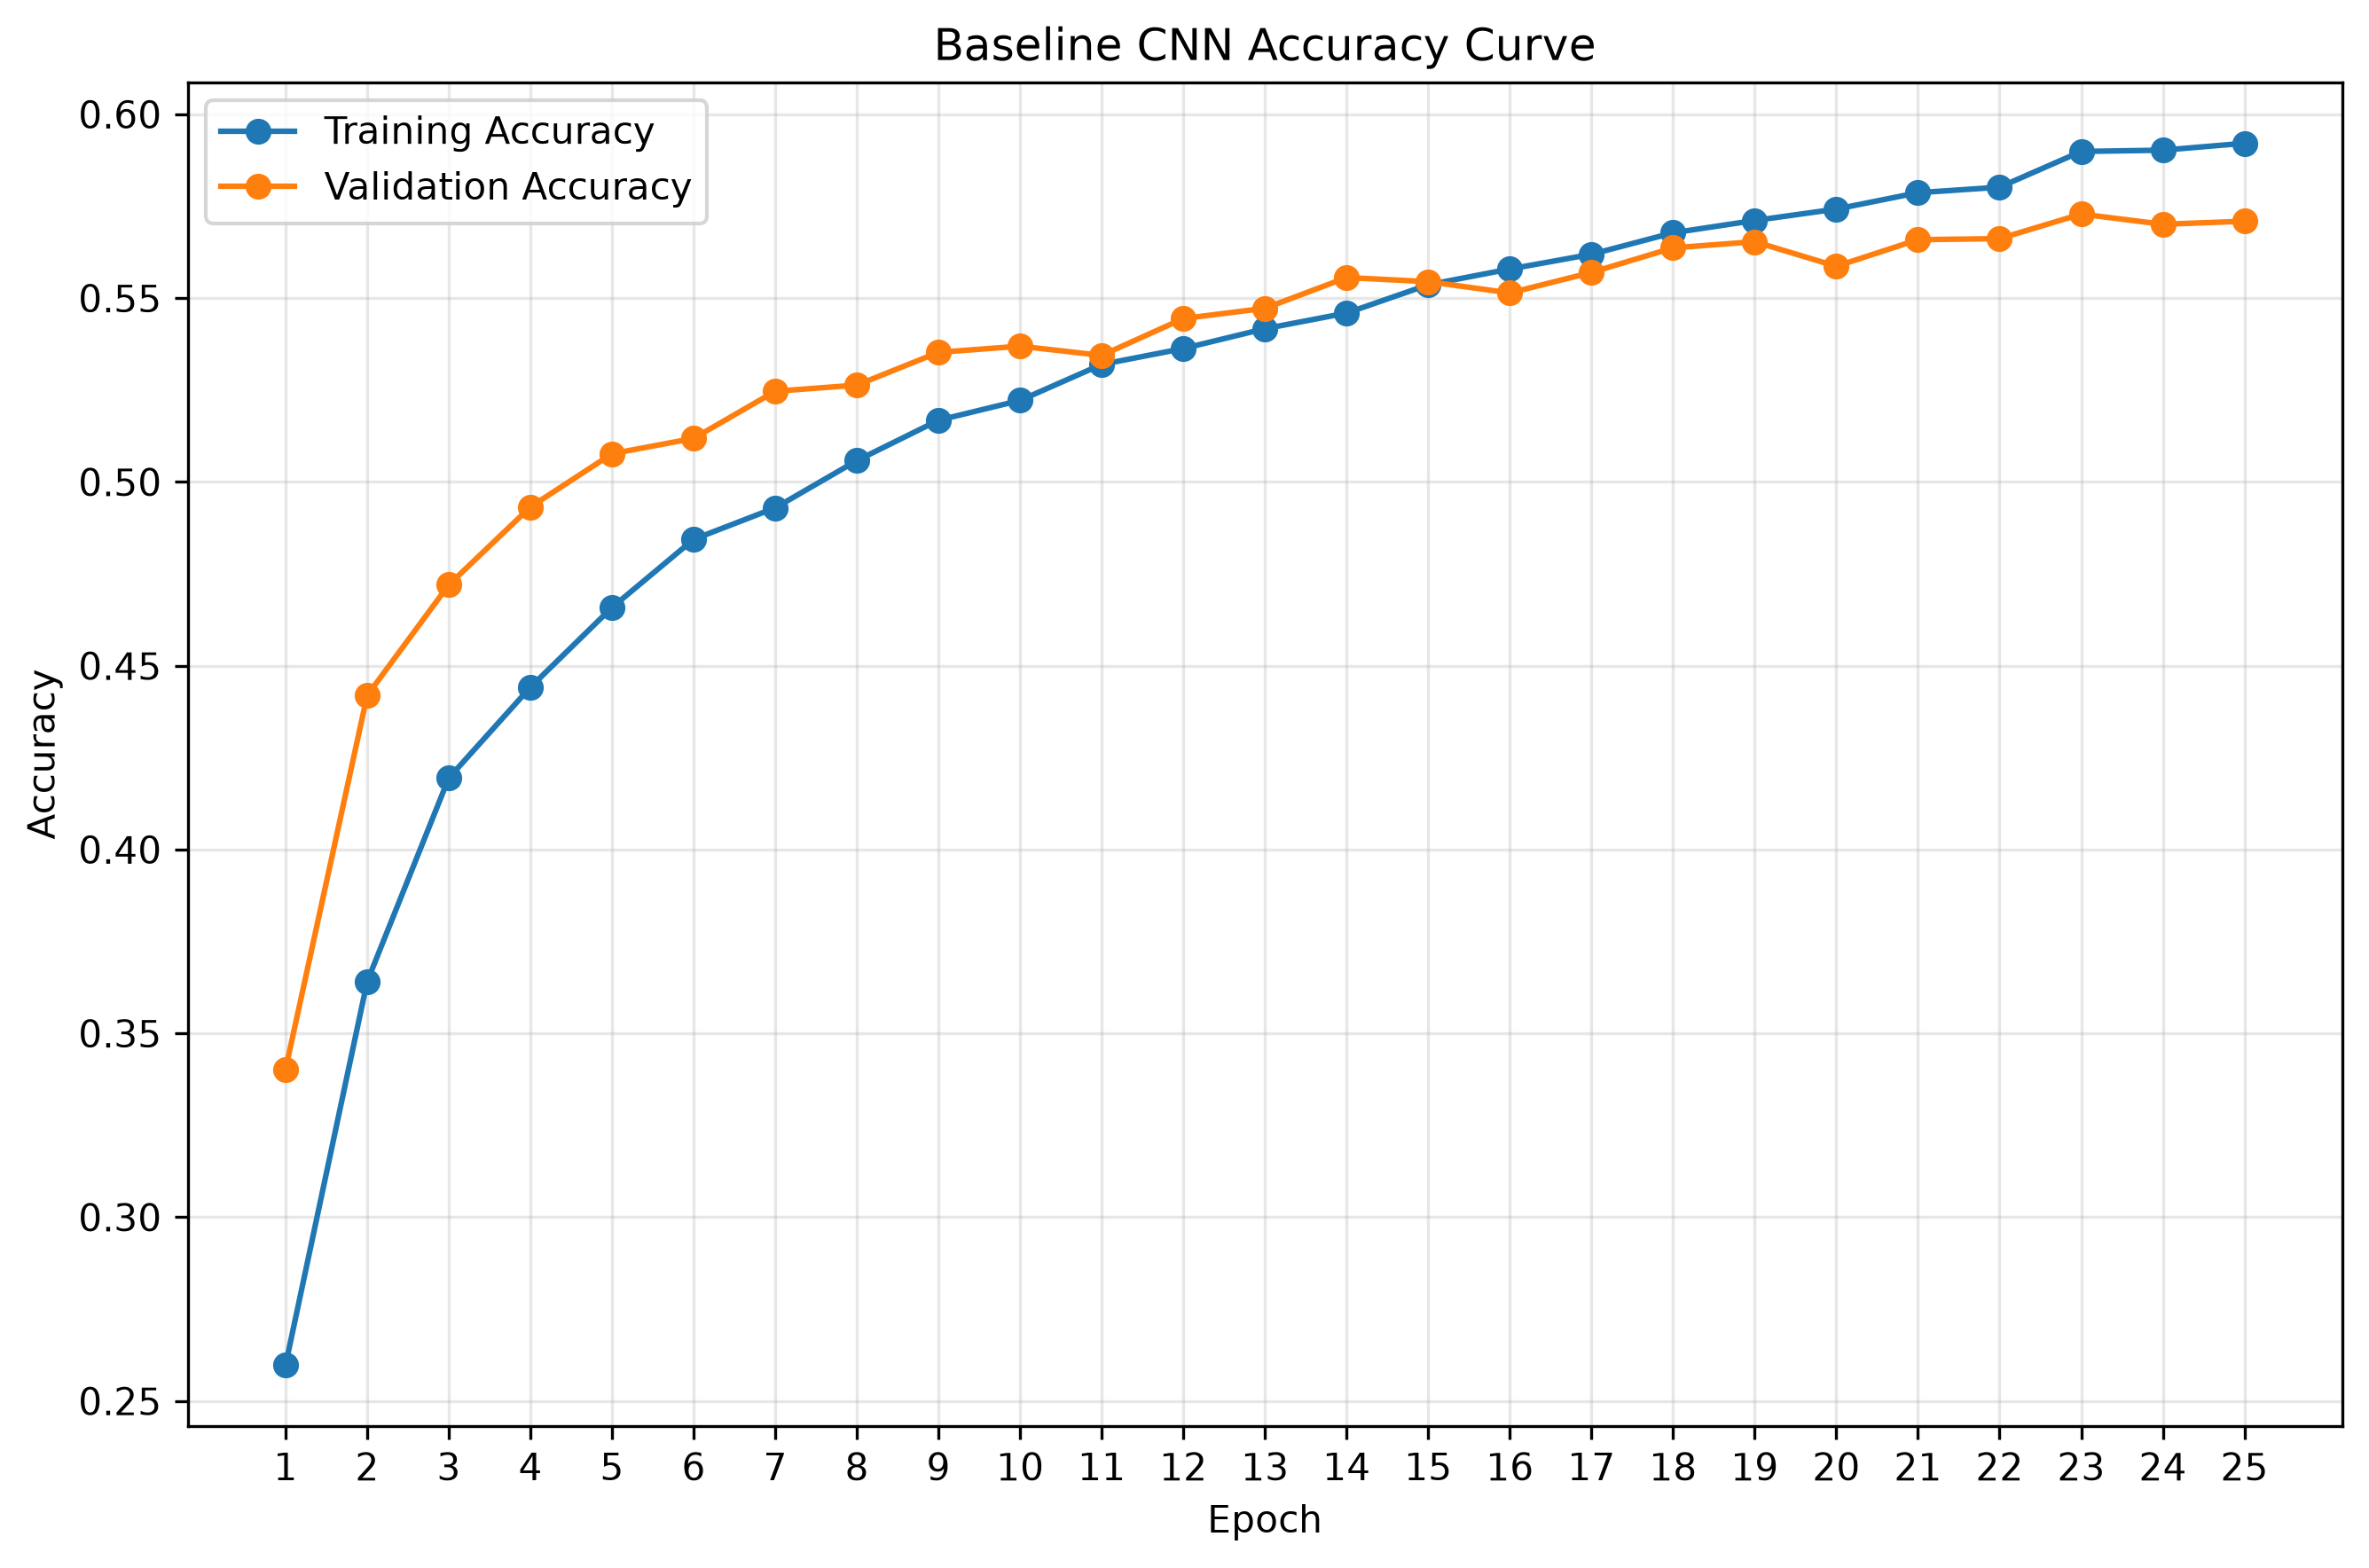

In [7]:
accuracy_curve_path = FIGURES_DIR / "baseline_cnn_accuracy_curve.png"
display(Image(filename=str(accuracy_curve_path)))

### Accuracy Curve Interpretation

A useful baseline model should show:

- Increasing training accuracy over epochs
- Increasing or stabilizing validation accuracy
- No extreme gap between training and validation accuracy

If the training accuracy continues improving while validation accuracy stops improving or decreases, the model may be overfitting.


## 9. Loss Curve

The loss curve shows how the optimization process behaves during training.


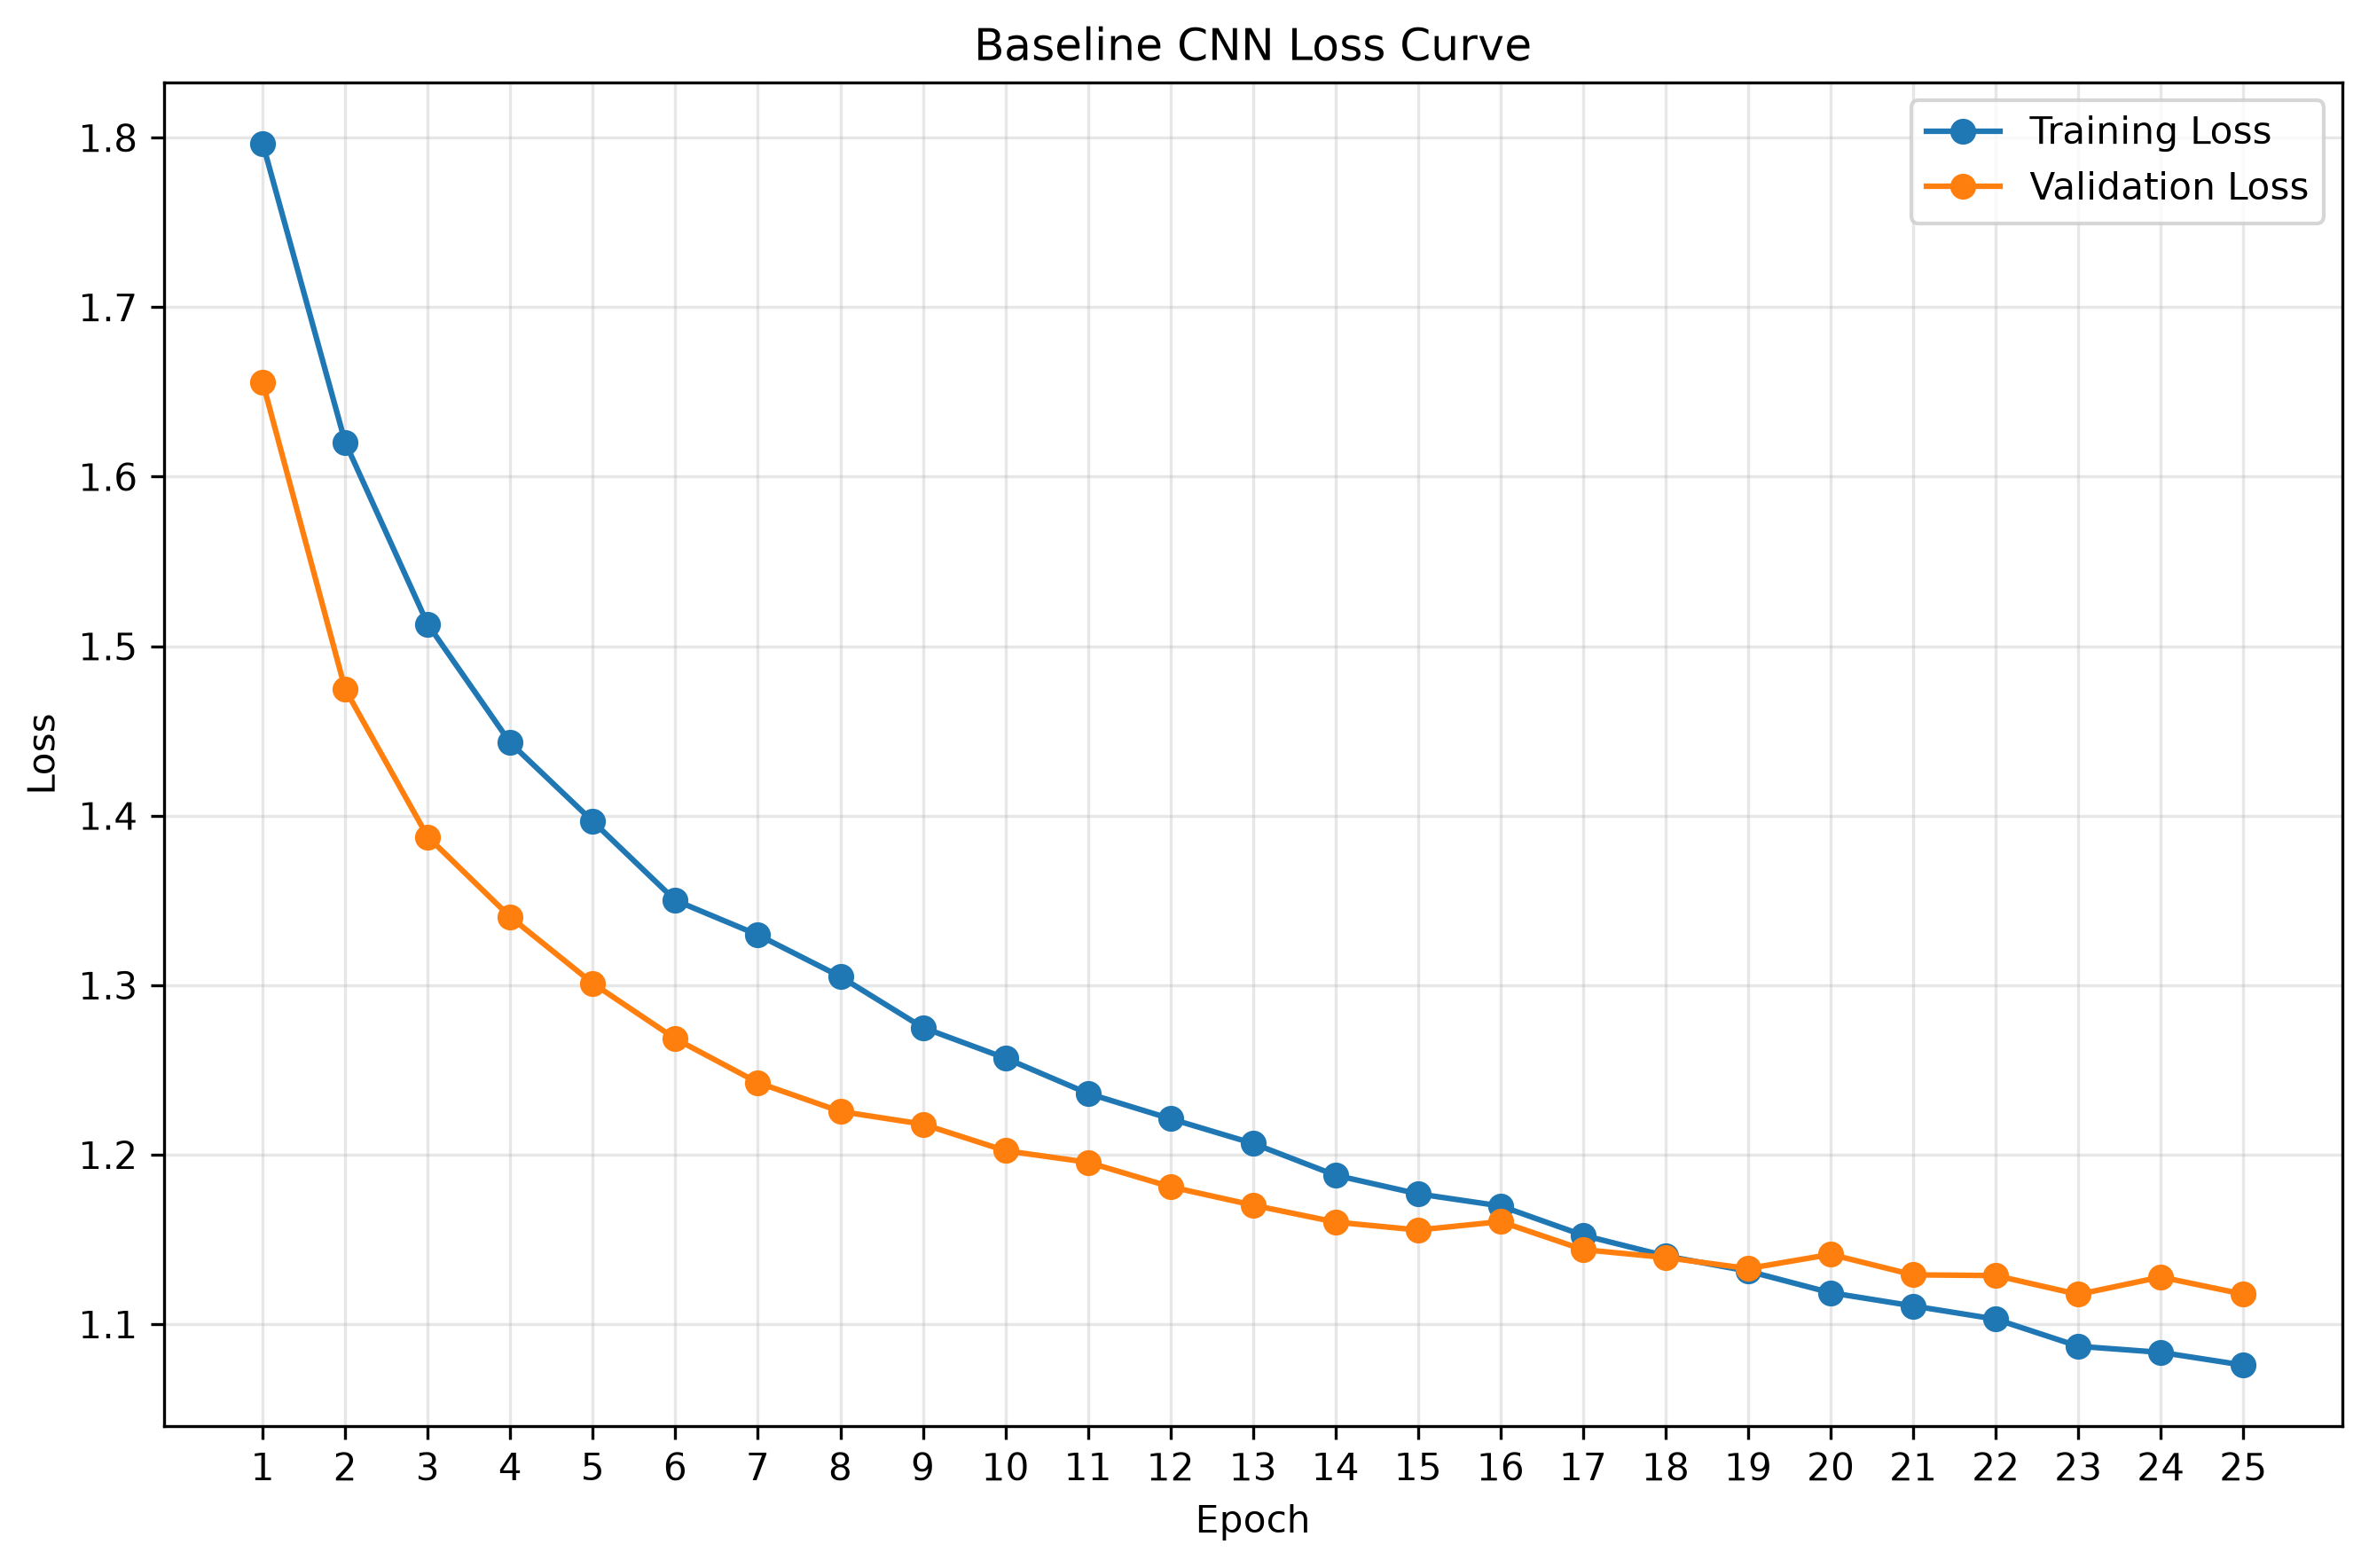

In [8]:
loss_curve_path = FIGURES_DIR / "baseline_cnn_loss_curve.png"
display(Image(filename=str(loss_curve_path)))

### Loss Curve Interpretation

A healthy baseline training run usually shows:

- Decreasing training loss
- Decreasing or stabilizing validation loss
- No severe divergence between training and validation loss

A rising validation loss while training loss decreases may indicate overfitting.


## 10. Validation Results

The validation set is used during model development to monitor generalization performance.

The baseline model checkpoint was selected using validation accuracy.


In [9]:
validation_results_path = METRICS_DIR / "baseline_cnn_validation_results.json"

with validation_results_path.open("r", encoding="utf-8") as file:
    validation_results = json.load(file)

validation_table = pd.DataFrame(
    {
        "Metric": list(validation_results.keys()),
        "Value": list(validation_results.values()),
    }
)

display(validation_table)

,Metric,Value
0,val_loss,1.117604
1,val_accuracy,0.572861
2,epochs_requested,25
3,batch_size,64
4,use_class_weights,False


## 11. Test Set Metrics

The test set is the final held-out evaluation set.

The following metrics are used:

- **Accuracy**: overall percentage of correct predictions
- **Macro Precision**: average precision across classes, treating all classes equally
- **Macro Recall**: average recall across classes, treating all classes equally
- **Macro F1**: average F1-score across classes
- **Weighted F1**: F1-score weighted by class support

Macro F1 is especially important for imbalanced datasets because it does not let large classes dominate the evaluation.


In [10]:
test_metrics_path = METRICS_DIR / "baseline_cnn_test_metrics.json"

with test_metrics_path.open("r", encoding="utf-8") as file:
    test_metrics = json.load(file)

test_metrics_table = pd.DataFrame(
    {
        "Metric": list(test_metrics.keys()),
        "Value": [round(float(value), 4) for value in test_metrics.values()],
    }
)

display(test_metrics_table)

,Metric,Value
0,test_loss,1.1067
1,test_accuracy_from_keras,0.5882
2,test_accuracy,0.5882
3,macro_precision,0.5912
4,macro_recall,0.5211
5,macro_f1,0.5304
6,weighted_f1,0.5731


## 12. Classification Report

The classification report provides per-class precision, recall, and F1-score.

This is more informative than accuracy alone because FER2013 is not perfectly balanced across classes.


In [11]:
classification_report_path = METRICS_DIR / "baseline_cnn_classification_report.txt"

with classification_report_path.open("r", encoding="utf-8") as file:
    report_text = file.read()

print(report_text)

              precision    recall  f1-score   support

       Angry       0.54      0.47      0.50       491
     Disgust       0.65      0.24      0.35        55
        Fear       0.56      0.24      0.34       528
       Happy       0.73      0.85      0.78       879
         Sad       0.43      0.46      0.44       594
    Surprise       0.73      0.72      0.73       416
     Neutral       0.50      0.67      0.57       626

    accuracy                           0.59      3589
   macro avg       0.59      0.52      0.53      3589
weighted avg       0.59      0.59      0.57      3589



## 13. Confusion Matrix

The confusion matrix shows which emotion classes are most often confused with each other.

Rows represent true labels, and columns represent predicted labels.


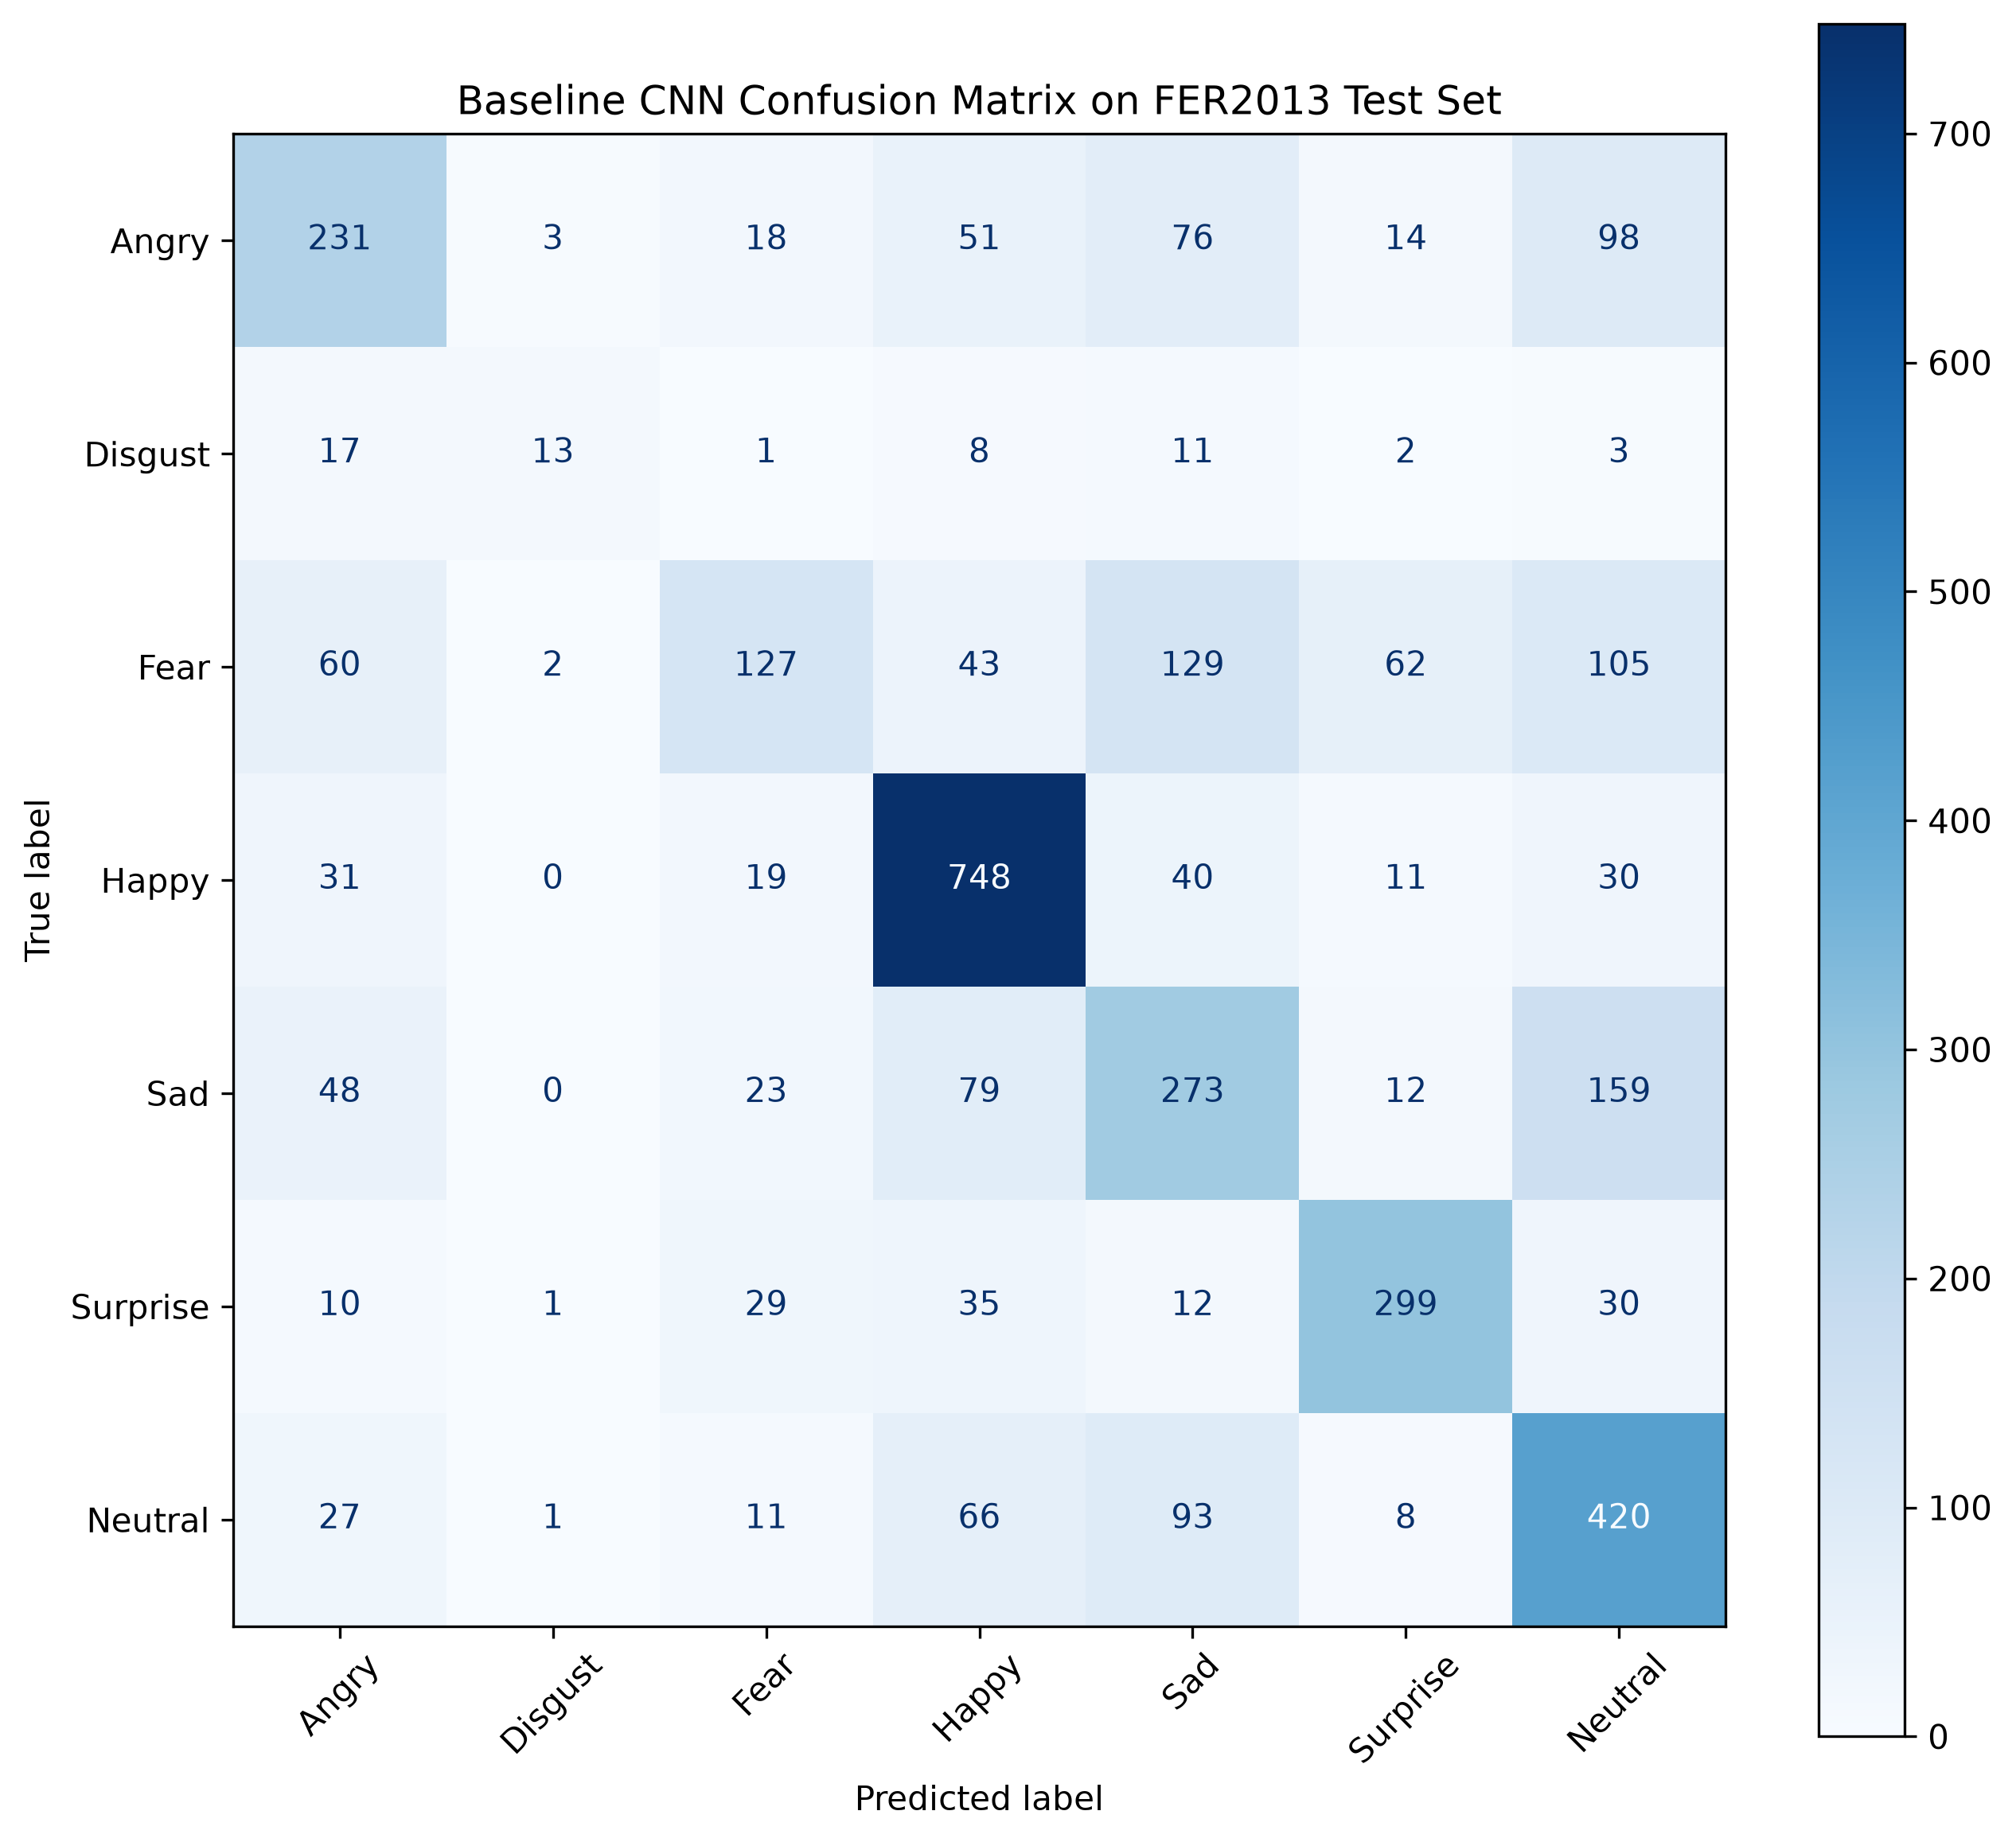

In [12]:
confusion_matrix_path = FIGURES_DIR / "baseline_cnn_confusion_matrix.png"
display(Image(filename=str(confusion_matrix_path)))

## 14. Main Observations

Based on the baseline results, the model shows a reasonable first-stage performance for a simple CNN.

### Stronger classes

The baseline CNN usually performs better on visually clearer expressions such as:

- **Happy**
- **Surprise**

These expressions often have stronger visual patterns, such as a clear smile or wide-open eyes.

### Weaker classes

The baseline model often struggles with:

- **Fear**
- **Disgust**
- **Sad**
- **Angry**

Possible reasons:

1. Some expressions are visually subtle.
2. Some classes have fewer training examples.
3. Low-resolution 48 × 48 images make fine facial details hard to detect.
4. Several emotions can look similar in grayscale images.
5. FER2013 contains noisy or ambiguous labels.

### Important note about Disgust

The `Disgust` class usually has much fewer samples than the other classes in FER2013. This can reduce recall and make the model less confident for this emotion.


## 15. Baseline Limitations

This baseline model is useful, but it has clear limitations:

1. It does not use data augmentation.
2. It does not use class weights.
3. It does not use batch normalization.
4. It uses a relatively simple architecture.
5. It does not perform confidence-threshold rejection.
6. It does not include temporal smoothing for real-time inference.
7. It does not include face alignment for external images or webcam input.

These limitations are intentionally left for the improved model and real-time inference stages.


## 16. Conclusion

The Baseline CNN successfully establishes a first performance benchmark for FER2013.

This stage produced:

- A trained baseline model
- Training and validation curves
- Validation metrics
- Test-set metrics
- A classification report
- A confusion matrix
- A clear understanding of common error patterns

### Next Step

The next stage is to build an **Improved CNN** using:

1. Batch Normalization
2. Data Augmentation
3. Class Weights
4. Learning-rate scheduling
5. Stronger regularization
6. Better model evaluation

The improved model will be compared against this baseline using validation accuracy, test accuracy, macro F1-score, weighted F1-score, and confusion matrix behavior.
